## RNN Assignment_20

### 1.Exploratory Data Analysis (EDA)

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# Load dataset
df = pd.read_csv('monthly_milk_production.csv')
df.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [4]:
# Convert 'Month' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Set Month as index
df.set_index('Date', inplace=True)

In [6]:
#shape
df.shape

(168, 1)

In [7]:
#data information
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 168 entries, 1962-01-01 to 1975-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Production  168 non-null    int64
dtypes: int64(1)
memory usage: 2.6 KB


#### Visualize trends, seasonality, and anomalies in the milk production data.

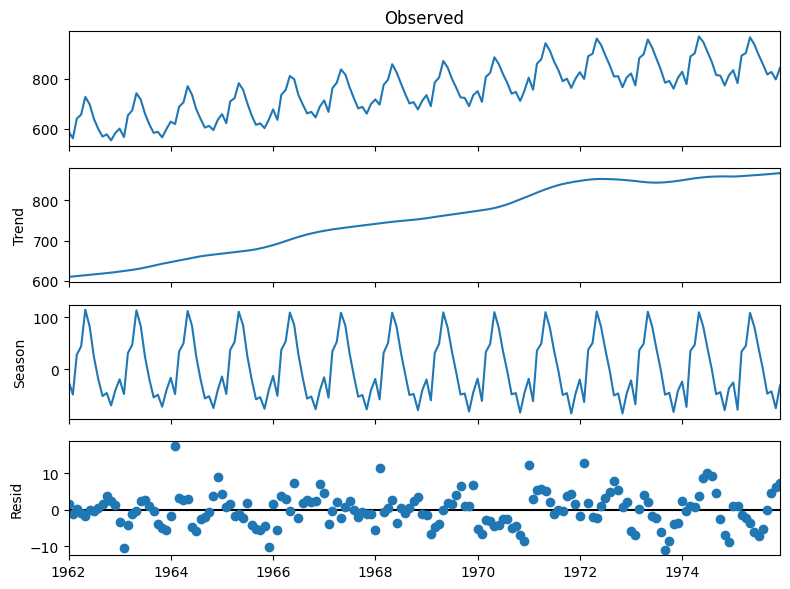

In [12]:
from statsmodels.tsa.seasonal import STL
stl = STL(df, period=12)
result = stl.fit()

# Plot decomposition
fig = result.plot()
fig.set_size_inches(8,6)

plt.tight_layout()
plt.show()

#### Check for any missing values or outliers.

In [13]:
# Check basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 168 entries, 1962-01-01 to 1975-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Production  168 non-null    int64
dtypes: int64(1)
memory usage: 2.6 KB


In [14]:
# Check missing values
df.isnull().sum()

Production    0
dtype: int64

#### Normalize or scale the data for neural network models.

In [15]:
from sklearn.preprocessing import MinMaxScaler

# Normalize data between 0 and 1
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

### 2.	Data Preparation for Deep Learning
#### Create input-output sequences (time windows) suitable for training RNNs/LSTMs/GRUs.


In [37]:
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

window_size = 12  # 1 year

In [38]:
# Create sequences
X, y = create_sequences(scaled_data, window_size)

print(X.shape, y.shape)

(156, 12, 1) (156, 1)


#### Split data into training, validation, and test sets.

In [42]:
# Split into train and test (80% train, 20% test)
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

#### Reshape data for model input dimensions.

In [43]:
# Check shapes
X_train.shape , y_train.shape, X_test.shape, y_test.shape

((124, 12, 1), (124, 1), (32, 12, 1), (32, 1))

### 3.	Model Building
#### Build three separate models:
+	Basic RNN
+	LSTM
+	GRU

In [49]:
# Train models
#Rnn Model
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(patience=5, restore_best_weights=True)

rnn_model = Sequential()
rnn_model.add(SimpleRNN(50, activation='tanh', input_shape=(window_size, 1)))
rnn_model.add(Dense(1))

rnn_model.compile(optimizer='adam', loss='mse')

# Train

rnn_model.fit(X_train, y_train,epochs=50,batch_size=16,validation_split=0.2,callbacks=[early_stop])

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0768 - val_loss: 0.0185
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0137 - val_loss: 0.0620
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0108 - val_loss: 0.0128
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0040 - val_loss: 0.0046
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0023 - val_loss: 0.0210
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0022 - val_loss: 0.0072
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0020 - val_loss: 0.0076
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0016 - val_loss: 0.0107
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0015 - val_loss: 0.0073


In [45]:
# Train models
#Lstm Model
lstm_model = Sequential()
lstm_model.add(LSTM(50, activation='relu', input_shape=(window_size, 1)))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer='adam', loss='mse')

lstm_model.fit(X_train, y_train, epochs=20, batch_size=16, verbose=1)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2305
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1457 
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0710 
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0327 
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0295
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0238
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0233
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0223
Epoch 9/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0219
Epoch 10/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0213 
Epoch 11/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0209 
Epoch 12/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0196
Epoch 13/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0188
Epoch 14/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0179 
Epoch 15/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0168
Epoch 16/20
8/8 ━━━━━━━━━━━━━━━━━━━

In [51]:
#Train models
#GRU Models
gru_model = Sequential()
gru_model.add(GRU(50, activation='relu', input_shape=(window_size, 1)))
gru_model.add(Dense(1))

gru_model.compile(optimizer='adam', loss='mse')

gru_model.fit(X_train, y_train, epochs=20, batch_size=16, verbose=1)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2637
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1869 
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1251 
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0723 
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0395
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0355 
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0306 
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0296 
Epoch 9/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0278 
Epoch 10/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0262 
Epoch 11/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0252 
Epoch 12/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0240 
Epoch 13/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0229
Epoch 14/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0225
Epoch 15/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0219
Epoch 16/20
8/8 ━━━━━━━━━━━━━━━━━━━

#### Tune hyperparameters (e.g., window size, number of units, batch size, epochs).

#### Use appropriate loss functions and optimizers.

### 4.	Model Evaluation
#### Plot predictions vs. actual values.


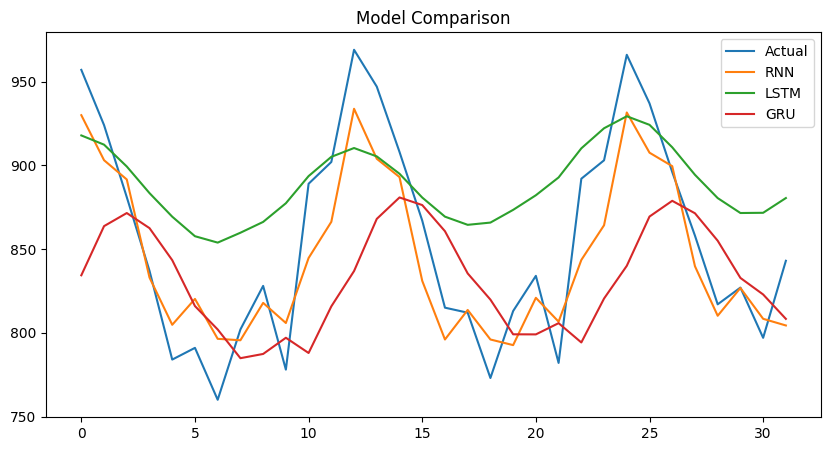

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_actual, label='Actual')
plt.plot(rnn_pred, label='RNN')
plt.plot(lstm_pred, label='LSTM')
plt.plot(gru_pred, label='GRU')
plt.legend()
plt.title('Model Comparison')
plt.show()

#### Calculate forecasting metrics: RMSE, MAE, MAPE.

In [55]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
# Function to evaluate model
def evaluate_model(model, X_test, y_test):
    pred = model.predict(X_test)

    # Convert back to original values
    pred = scaler.inverse_transform(pred)
    y_actual = scaler.inverse_transform(y_test)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_actual, pred))
    mae = mean_absolute_error(y_actual, pred)
    mape = np.mean(np.abs((y_actual - pred) / y_actual)) * 100

    return pred, y_actual, rmse, mae, mape


# Evaluate all models
rnn_pred, y_actual, rnn_rmse, rnn_mae, rnn_mape = evaluate_model(rnn_model, X_test, y_test)
lstm_pred, _, lstm_rmse, lstm_mae, lstm_mape = evaluate_model(lstm_model, X_test, y_test)
gru_pred, _, gru_rmse, gru_mae, gru_mape = evaluate_model(gru_model, X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


In [56]:
# Print results
print("RNN:", rnn_rmse, rnn_mae, rnn_mape)
print("LSTM:", lstm_rmse, lstm_mae, lstm_mape)
print("GRU:", gru_rmse, gru_mae, gru_mape)

RNN: 26.634459439925294 22.95568275451659 2.657037533066942
LSTM: 54.25971989848075 45.88723945617676 5.569429628052942
GRU: 60.533962223770246 48.539459228515625 5.506509006003333


#### Compare the performance of RNN, LSTM, and GRU.

### 5.	Prediction and Visualization
#### Forecast milk production for the next 12 months.


In [61]:
# Function to forecast future values
def forecast_future(model, data, window_size, steps):
    
    # Take last window
    temp_input = data[-window_size:]
    temp_input = temp_input.reshape(1, window_size, 1)

    output = []

    for _ in range(steps):
        # Predict next value
        pred = model.predict(temp_input)
        
        # Store prediction
        output.append(pred[0][0])

        # Reshape prediction to match input shape
        pred_reshaped = pred.reshape(1,1,1)

        # Update input sequence (remove first, add new prediction)
        temp_input = np.append(temp_input[:,1:,:], pred_reshaped, axis=1)

    # Convert back to original scale
    return scaler.inverse_transform(np.array(output).reshape(-1,1))


# Forecast next 12 months (use best model → RNN)
future = forecast_future(rnn_model, scaled_data, window_size, 12)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


In [62]:
# Print results
print("Next 12 months forecast:\n", future)

Next 12 months forecast:
 [[829.0768 ]
 [804.41   ]
 [843.3147 ]
 [860.4546 ]
 [906.0364 ]
 [901.2845 ]
 [886.2562 ]
 [846.41315]
 [814.176  ]
 [830.14154]
 [821.16   ]
 [840.9251 ]]


#### Visualize the predicted trend with uncertainty or confidence intervals if possible.

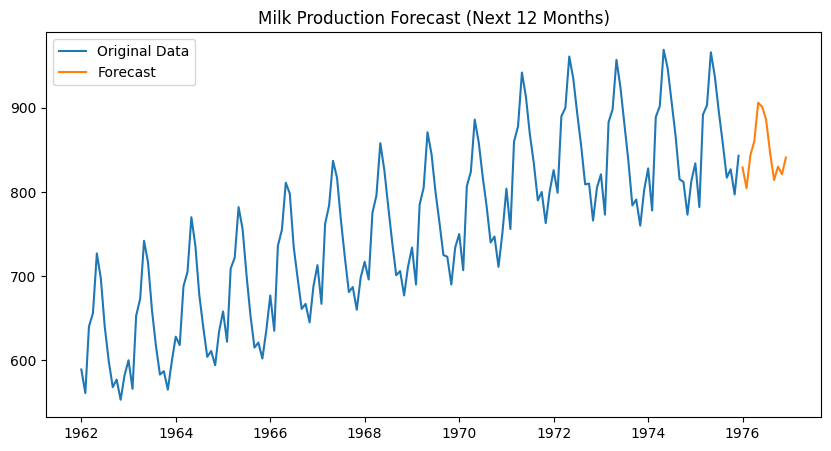

In [67]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# 🔹 Plot
plt.figure(figsize=(10,5))

# Original data
plt.plot(df.index, df.iloc[:,0], label='Original Data')

# Future dates (FIX: use 'MS')
future_dates = pd.date_range(start=df.index[-1], periods=13, freq='MS')[1:]

# Forecast
plt.plot(future_dates, future, label='Forecast')

plt.legend()
plt.title('Milk Production Forecast (Next 12 Months)')
plt.show()

### 6.	Business Insights
#### Interpret results and recommend how the dairy business can use these forecasts for better planning and resource allocation
